In [1]:
import sys
from pathlib import Path
repo_root = Path.cwd()
sys.path.insert(0, str(repo_root / 'prob_cGAN_for_GEO_QPE/src'))
import prob_cGAN as pcgan
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from tqdm import tqdm
from torch.utils.data import DataLoader
from torchinfo import summary

# Set up variables
model_path = repo_root / 'prob_cGAN_for_GEO_QPE/model' / 'generator.pth'
config = pcgan.load_config(str(repo_root / 'prob_cGAN_for_GEO_QPE/model' / 'config.yaml'))
selected_channels = config['data']['selected_channels']
n_lat,n_lon = 164,280
prev_time = config['data']['prev_time'] # number of previous time steps used as input
a = config['data']['a'] # normalization constant for precipitation
members = 1 # number of ensemble members to generate

In [2]:
# load the combined dataset
ds_combined = xr.open_zarr('prob_cGAN_for_GEO_QPE/data/input_target_benchmark.zarr')
ds_combined


<xarray.Dataset> Size: 49MB
Dimensions:               (time: 48, channel: 2, tstep: 2, x: 164, y: 280,
                           time_hr: 12)
Coordinates:
  * time                  (time) datetime64[ns] 384B 2019-04-27T15:10:00 ... ...
  * time_hr               (time_hr) datetime64[ns] 96B 2019-04-27T15:00:00 .....
Dimensions without coordinates: channel, tstep, x, y
Data variables:
    seviri_channels_norm  (time, channel, tstep, x, y) float32 35MB ...
    lon                   (x, y) float64 367kB ...
    radklim-yw            (time, x, y) float32 9MB ...
    pdir_now              (time_hr, x, y) float64 4MB ...
    lat                   (x, y) float64 367kB ...
Attributes:
    description:  Combined dataset for input, target, benchmark, including pd...

In [8]:


pdir_now = ds_combined['pdir_now'].values
target = ds_combined['radklim-yw'].values
input = ds_combined['seviri_channels_norm'].values
lon = ds_combined['lon'].values
lat = ds_combined['lat'].values
time = ds_combined['time'].values
time_pdir_now = ds_combined['time_hr'].values
print('Information about the dataset:')
print(f'shape of input:         {input.shape}, dtype: {input.dtype} min val: {np.nanmin(input)}, max value: {np.nanmax(input)}')
print(f'shape of target:        {target.shape}, dtype: {target.dtype} min val: {np.nanmin(target)}, max value: {np.nanmax(target)}')
print(f'shape of pdir_now:      {pdir_now.shape}, dtype: {pdir_now.dtype} min val: {np.nanmin(pdir_now)}, max value: {np.nanmax(pdir_now)}')
print(f'shape of lon:           {lon.shape}, dtype: {lon.dtype}')
print(f'shape of lat:           {lat.shape}, dtype: {lat.dtype}')
print(f'shape of time:          {time.shape}, dtype: {time.dtype}')
print(f'shape of time_pdir_now: {time_pdir_now.shape}, dtype: {time_pdir_now.dtype} (start of accum hour)')


# Normalize target
target_norm = pcgan.norm_precip(target,a)

print('Prediction generation:')
ds = pcgan.Custom_Dataset(x=input, y=target_norm)
data_loader = DataLoader(dataset=ds, batch_size=100, shuffle=False)
generator =  pcgan.Unet_ensemble_3D_alldropout(T_in=config.model.in_time,in_channels=config.model.in_channels,in_features_G=config.model.in_features_G,dropout_cfg=config.dropout).cpu()
#summary(generator, input_size=(1,config.model.in_time, config.model.in_channels, n_lat, n_lon))
predictions=np.empty((members,len(target_norm),n_lat,n_lon))
mask = np.isfinite(target) # 
for i in tqdm(range(members)):
    predictions_norm,_,_ = pcgan.calc_prediction(generator,model_path,data_loader,seed=1+i)
    predictions[i] = pcgan.reverse_norm_precip(predictions_norm,a).squeeze()
    # target mask application
    predictions[i][~mask] = np.nan


Information about the dataset:
shape of input:         (48, 2, 2, 164, 280), dtype: float32 min val: 0.13963186740875244, max value: 0.9456124305725098
shape of target:        (48, 164, 280), dtype: float32 min val: 0.0, max value: 12.296011924743652
shape of pdir_now:      (12, 164, 280), dtype: float64 min val: 0.0, max value: 11.975101470445026
shape of lon:           (164, 280), dtype: float64
shape of lat:           (164, 280), dtype: float64
shape of time:          (48,), dtype: datetime64[ns]
shape of time_pdir_now: (12,), dtype: datetime64[ns] (start of accum hour)
Prediction generation:


  0%|                                                                                                | 0/1 [00:00<?, ?it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.98s/it]


In [4]:
summary(generator, input_size=(1,config.model.in_time, config.model.in_channels, n_lat, n_lon))

Layer (type:depth-idx)                   Output Shape              Param #
Unet_ensemble_3D_alldropout              [1, 1, 1, 164, 280]       --
├─ModuleList: 1-4                        --                        (recursive)
│    └─ResNetBlock3D: 2-1                [1, 32, 2, 164, 280]      --
│    │    └─Sequential: 3-1              [1, 32, 2, 164, 280]      29,568
│    │    └─Conv3d: 3-2                  [1, 32, 2, 164, 280]      96
├─Dropout3d: 1-2                         [1, 32, 2, 164, 280]      --
├─MaxPool3d: 1-3                         [1, 32, 1, 82, 140]       --
├─ModuleList: 1-4                        --                        (recursive)
│    └─ResNetBlock3D: 2-2                [1, 64, 1, 82, 140]       --
│    │    └─Sequential: 3-3              [1, 64, 1, 82, 140]       166,272
│    │    └─Conv3d: 3-4                  [1, 64, 1, 82, 140]       2,112
├─Dropout: 1-5                           [1, 64, 1, 82, 140]       --
├─MaxPool3d: 1-6                         [1, 64, 1, 41,

/bg/fast/env_janner-s/mambaforge/envs/cGANQPEenv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/bg/fast/env_janner-s/mambaforge/envs/cGANQPEenv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/bg/fast/env_janner-s/mambaforge/envs/cGANQPEenv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/bg/fast/env_janner-s/mambaforge/envs/cGANQPEenv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effe

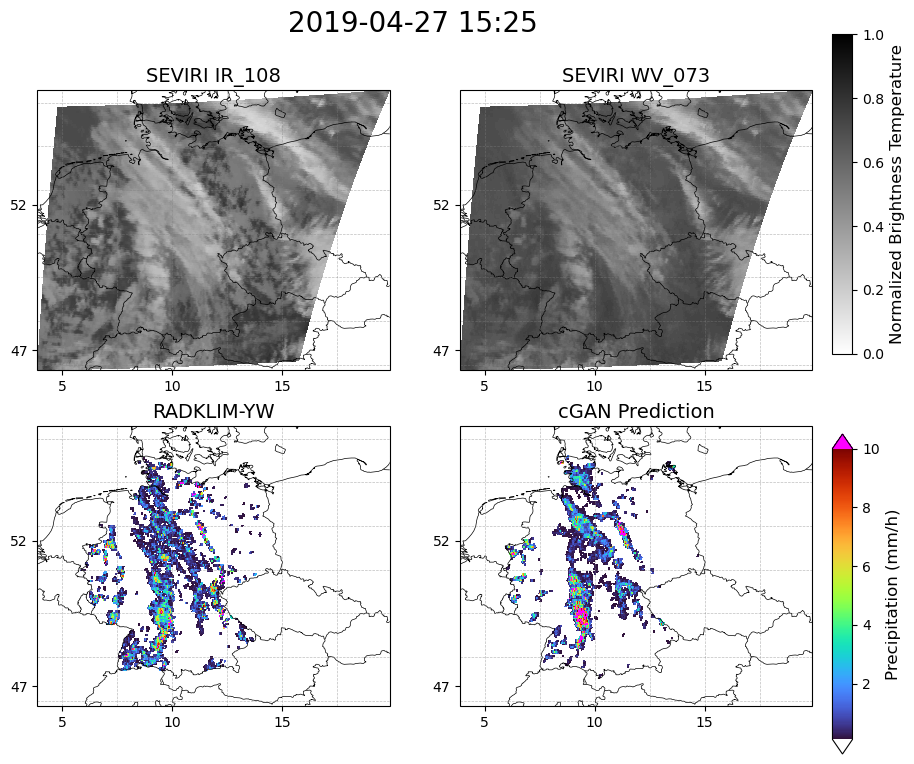

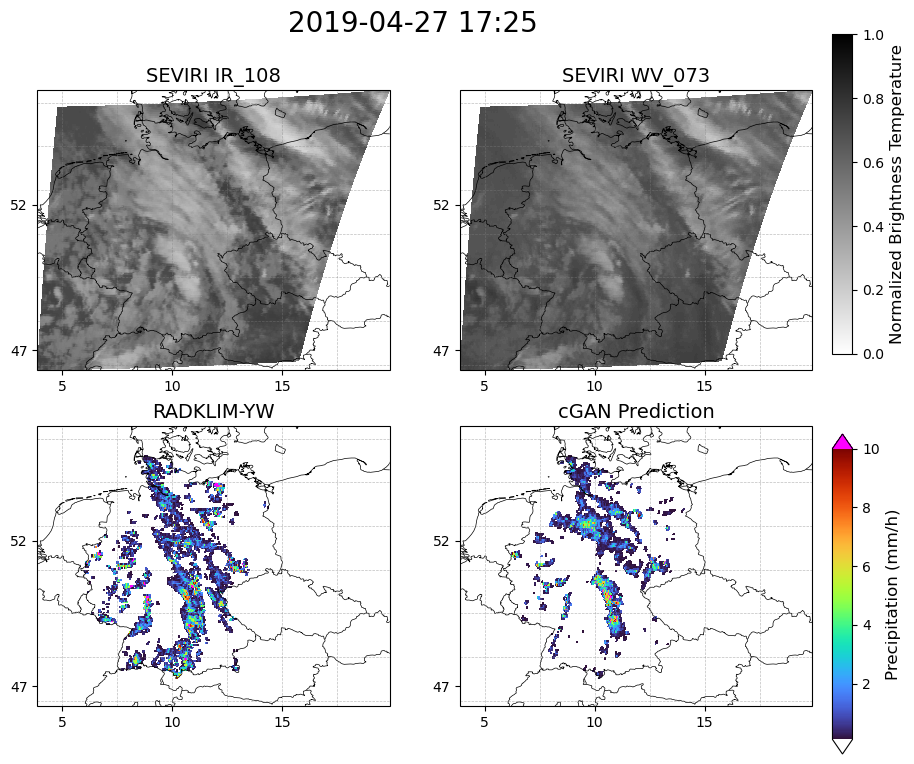

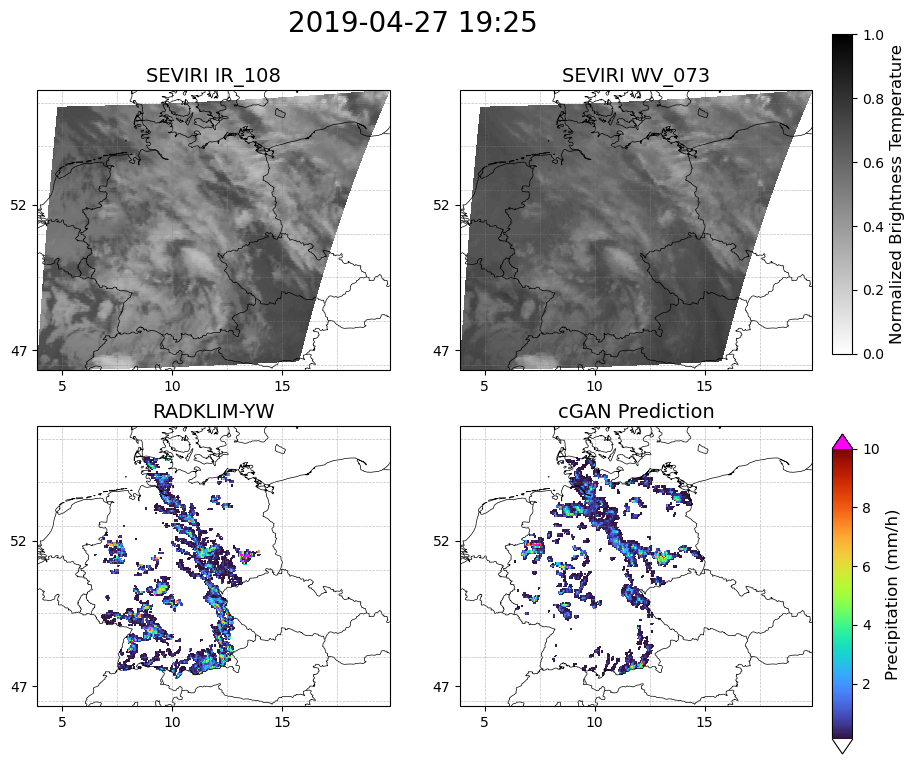

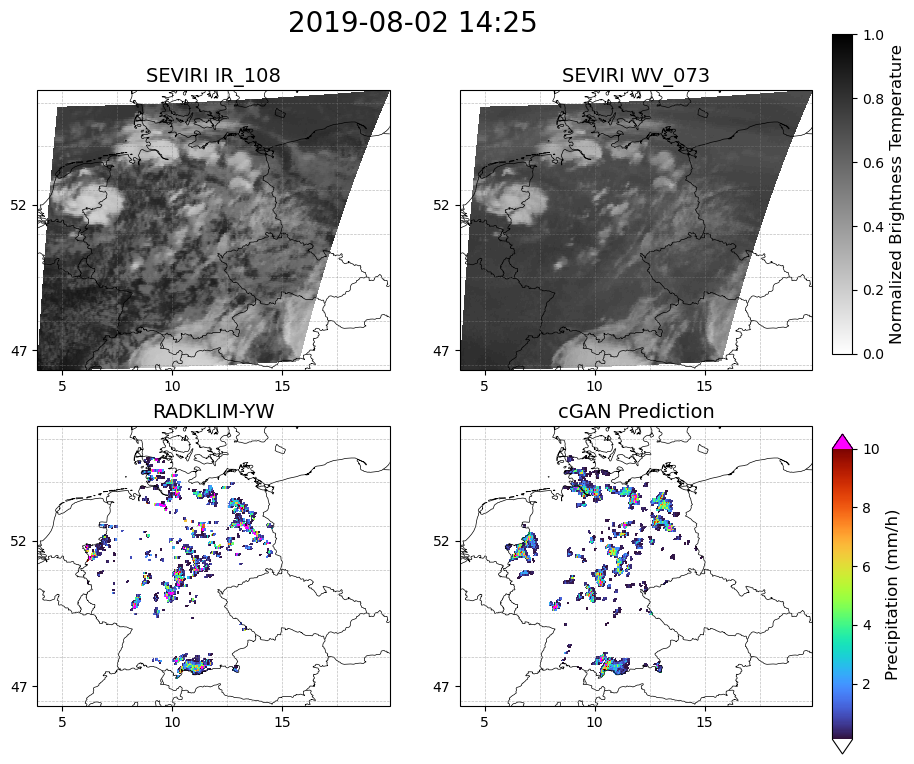

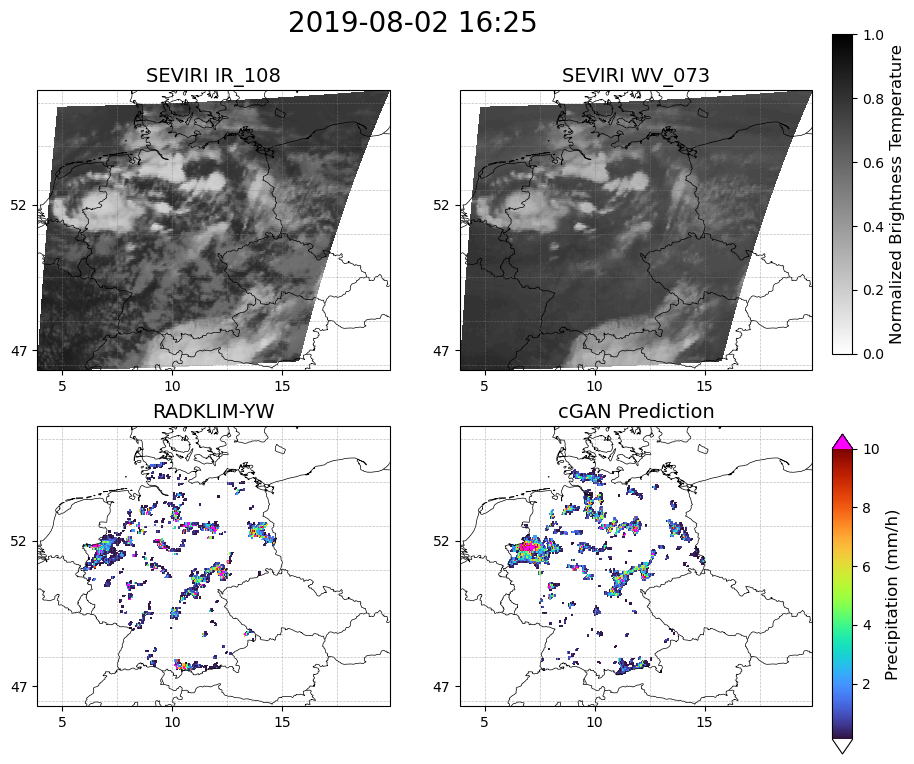

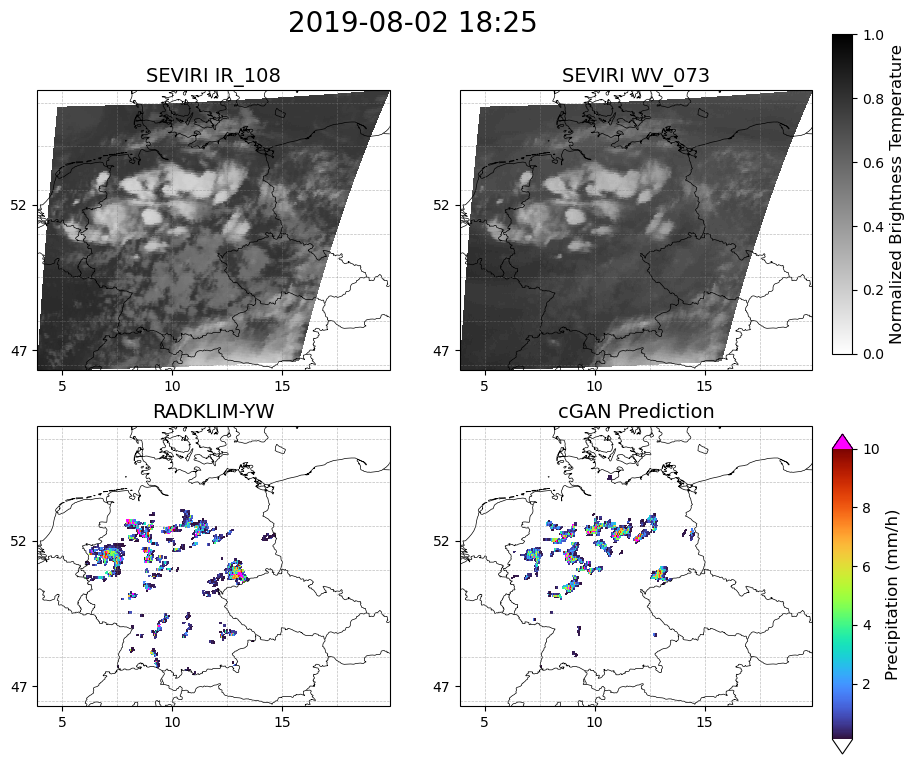

In [5]:
turbo_custom = plt.get_cmap('turbo')
turbo_custom.set_under('none')
turbo_custom.set_over('magenta')
turbo_custom.set_bad('lightgray', alpha=0.3)

proj = ccrs.PlateCarree()

for index_example in np.arange(1, len(target), step=8):
    fig, ax = plt.subplots(2,2, figsize=(10,8), subplot_kw={'projection': proj})

    p1=ax[0,0].pcolor(lon,lat,input[index_example,0,0], cmap='gray_r',vmin=0, vmax=1)
    ax[0,0].set_title(f'SEVIRI {selected_channels[1]}')
    ax[0,0].title.set_fontsize(14)
    ax[0,1].set_title(f'SEVIRI {selected_channels[2]}')
    ax[0,1].title.set_fontsize(14)
    ax[0,1].pcolor(lon,lat,input[index_example,1,0], cmap='gray_r',vmin=0, vmax=1)

    ax[1,0].set_title('RADKLIM-YW')
    ax[1,0].title.set_fontsize(14)
    p2=ax[1,0].pcolor(lon,lat,target[index_example]*12, cmap=turbo_custom, vmin=0.1, vmax=10)

    ax[1,1].set_title('cGAN Prediction')
    ax[1,1].title.set_fontsize(14)
    ax[1,1].pcolor(lon,lat,predictions[0,index_example]*12, cmap=turbo_custom, vmin=0.1, vmax=10)

    # iterate over axes to add features
    for i in range(2):
        for j in range(2):
            ax[i,j].add_feature(cfeature.BORDERS,color='k', linewidth=0.5)
            ax[i,j].add_feature(cfeature.COASTLINE,color='k', linewidth=0.5)

            ax[i,j].set_aspect('auto')

            ax[i,j].set_xticks(np.arange(5,20,5))
            ax[i,j].set_yticks(np.arange(47,55,5))
            ax[i,j].set_xticklabels(np.arange(5,20,5))
            ax[i,j].set_yticklabels(np.arange(47,55,5))

            gridlines = ax[i,j].gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

    plt.suptitle(
        f"{time[index_example].astype(str).replace('T', ' ')[:16]}",
        fontsize=20
    )

    # Add colorbar for the precipitation plots
    cbar_ax = fig.add_axes([0.92, 0.05, 0.02, 0.4])  # [left, bottom, width, height]
    cbar = fig.colorbar(p2, cax=cbar_ax,extend='both')
    cbar.set_label('Precipitation (mm/h)', fontsize=12)
    cbar.ax.tick_params(labelsize=10)
    # add colorbar for the SEVIRI plots
    cbar_ax2 = fig.add_axes([0.92, 0.55, 0.02, 0.4])  #[left, bottom, width, height]
    cbar2 = fig.colorbar(p1, cax=cbar_ax2)
    cbar2.set_label('Normalized Brightness Temperature', fontsize=12)
    cbar2.ax.tick_params(labelsize=10)

In [6]:
# hourly target and prediction
_,target_hr = pcgan.calculate_hourly_precip(time, target)
print(target.shape,predictions.shape)
_,predictions_hr = pcgan.calculate_hourly_precip(time, np.squeeze(predictions))

(48, 164, 280) (1, 48, 164, 280)


/bg/fast/env_janner-s/mambaforge/envs/cGANQPEenv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/bg/fast/env_janner-s/mambaforge/envs/cGANQPEenv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/bg/fast/env_janner-s/mambaforge/envs/cGANQPEenv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/bg/fast/env_janner-s/mambaforge/envs/cGANQPEenv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effe

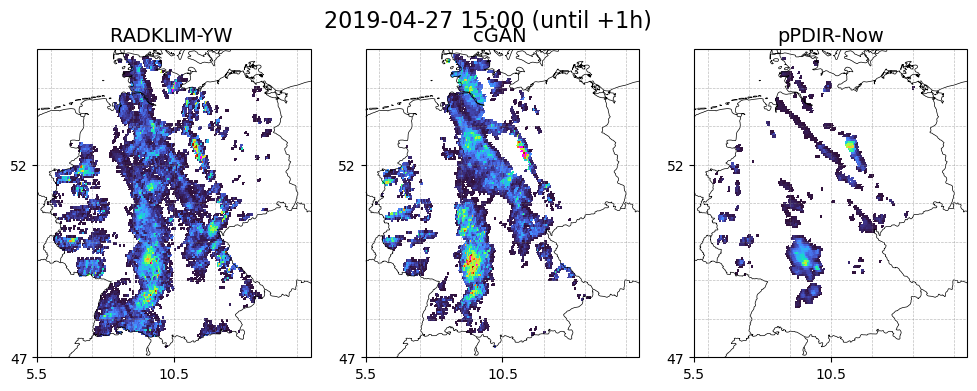

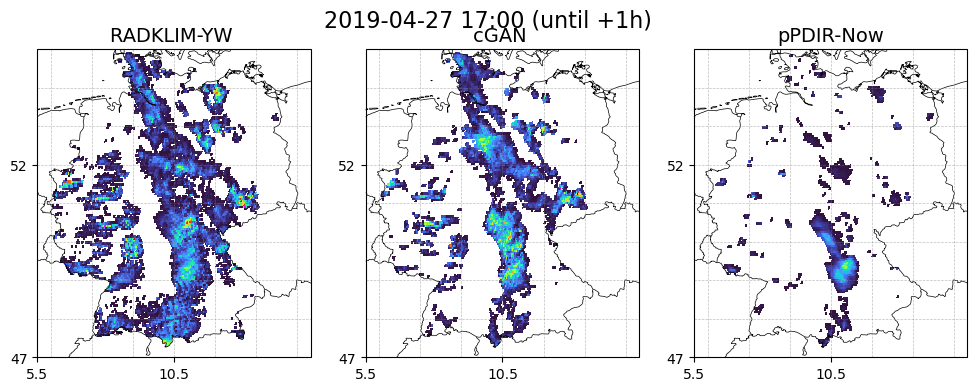

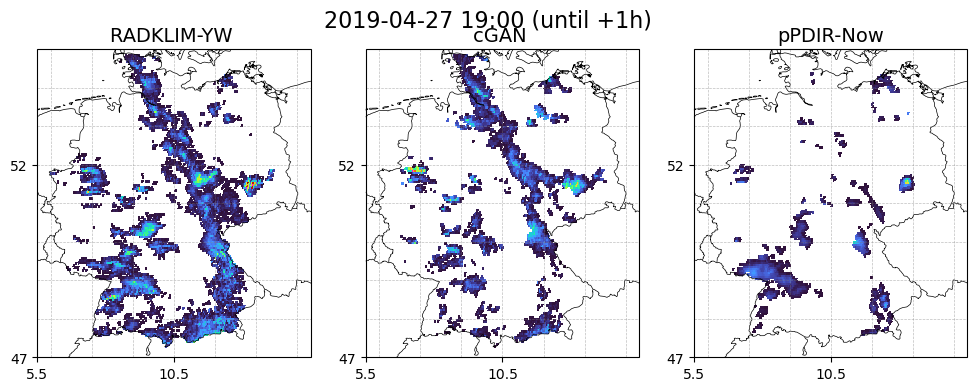

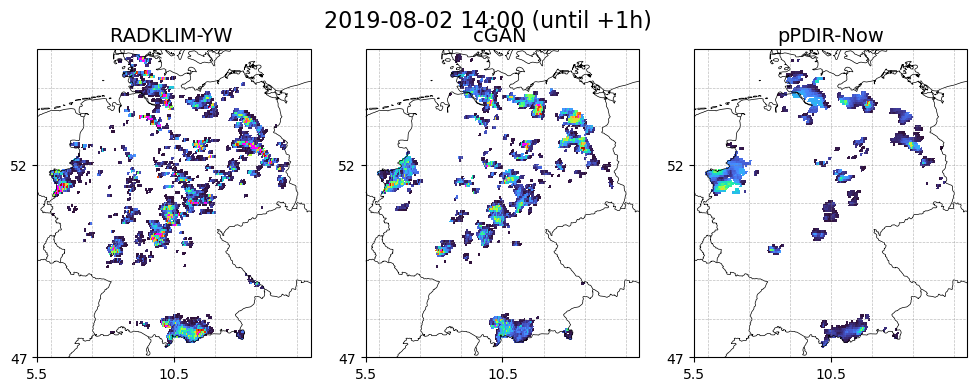

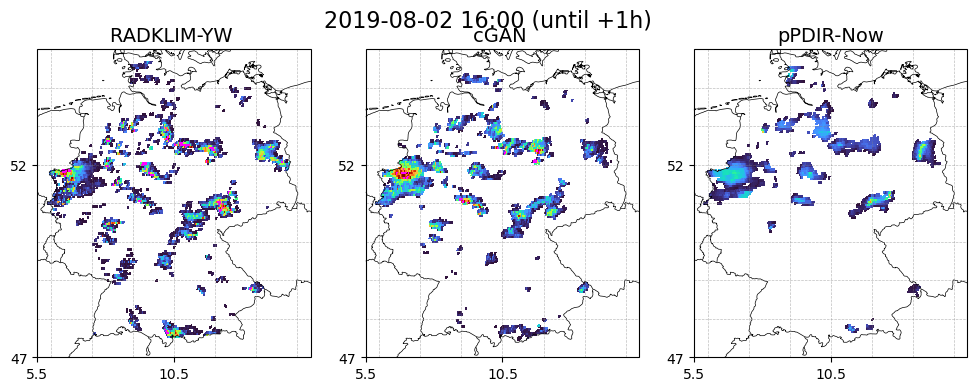

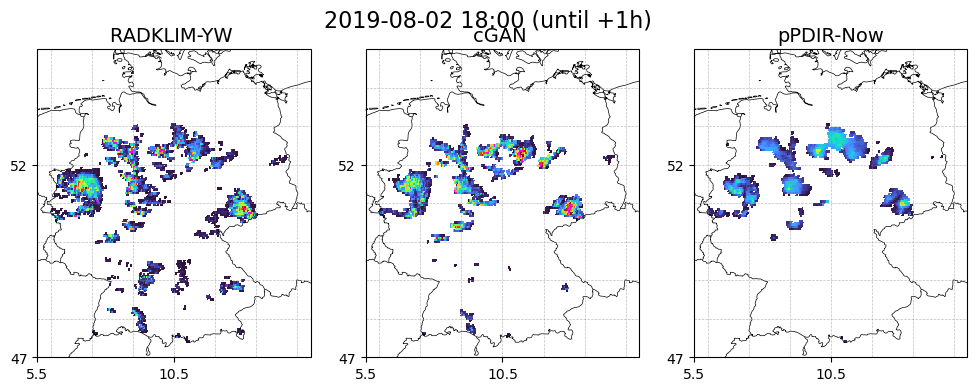

In [7]:
for index_example in np.arange(0,len(target_hr), step=2):
    fig,axs = plt.subplots(1,3, figsize=(12,4), subplot_kw={'projection': proj})

    plt.suptitle(f"{time_pdir_now[index_example].astype(str).replace('T', ' ')[:16]} (until +1h)", fontsize=16)

    axs[0].set_title(F'RADKLIM-YW ')
    axs[0].title.set_fontsize(14)
    p2=axs[0].pcolor(lon,lat,target_hr[index_example], cmap=turbo_custom, vmin=0.1, vmax=10)

    axs[1].set_title(F'cGAN ')
    axs[1].title.set_fontsize(14)
    axs[1].pcolor(lon,lat,np.where(target_hr[index_example]>0, predictions_hr[index_example], np.nan), cmap=turbo_custom, vmin=0.1, vmax=10)

    axs[2].set_title(F'pPDIR-Now')
    axs[2].title.set_fontsize(14)
    axs[2].pcolor(lon, lat, np.where(target_hr[index_example]>0, pdir_now[index_example], np.nan), cmap=turbo_custom, vmin=0.1, vmax=10)

    # iterate over axes to add features
    for i in range(3):
        axs[i].add_feature(cfeature.BORDERS,color='k', linewidth=0.5)
        axs[i].add_feature(cfeature.COASTLINE,color='k', linewidth=0.5)

        axs[i].set_aspect('auto')

        axs[i].set_xticks(np.arange(5.5,15.5,5))
        axs[i].set_yticks(np.arange(47,55,5))
        axs[i].set_xticklabels(np.arange(5.5,15.5,5))
        axs[i].set_yticklabels(np.arange(47,55,5))
        # extent
        axs[i].set_extent([5.5,15.5,47,55], crs=proj)

        gridlines = axs[i].gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
